In [4]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import soundfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Data Preprocessing (Changing audio files names)

In [5]:
import os

def rename_audio_files(folder_path, prefix="Emotion-Neutral-04"):
    """
    Rename audio files in the given folder with a specified prefix and 3-digit numbering.
    
    Args:
        folder_path (str): Path to the folder containing the audio files.
        prefix (str): Prefix for the new file names.
        
    Returns:
        None
    """
    try:
        # Get all files in the folder
        files = os.listdir(folder_path)
        audio_files = [file for file in files if file.endswith((".wav", ".mp3"))]

        # Rename each file with padded numbering
        for index, file_name in enumerate(audio_files, start=1):
            # Extract the file extension
            file_extension = os.path.splitext(file_name)[1]
            # Create a new file name with 3-digit padded numbering
            new_name = f"{prefix}-{index:03}{file_extension}"
            old_file_path = os.path.join(folder_path, file_name)
            new_file_path = os.path.join(folder_path, new_name)

            # Rename the file
            os.rename(old_file_path, new_file_path)
            print(f"Renamed: {file_name} -> {new_name}")

        print("\nRenaming completed.")
    except Exception as e:
        print(f"Error: {e}")

# Example usage
folder_path = "C:\\xampp\\htdocs\\FYP\\Emotion-Detection-System\\processed_2_seconds_Main\\Emotion_04"  # Replace with your folder path
rename_audio_files(folder_path, prefix="Emotion-Neutral-04")


Renamed: Emotion-Neutral-04-001.wav -> Emotion-Neutral-04-001.wav
Renamed: Emotion-Neutral-04-002.wav -> Emotion-Neutral-04-002.wav
Renamed: Emotion-Neutral-04-003.wav -> Emotion-Neutral-04-003.wav
Renamed: Emotion-Neutral-04-004.wav -> Emotion-Neutral-04-004.wav
Renamed: Emotion-Neutral-04-005.wav -> Emotion-Neutral-04-005.wav
Renamed: Emotion-Neutral-04-006.wav -> Emotion-Neutral-04-006.wav
Renamed: Emotion-Neutral-04-007.wav -> Emotion-Neutral-04-007.wav
Renamed: Emotion-Neutral-04-008.wav -> Emotion-Neutral-04-008.wav
Renamed: Emotion-Neutral-04-009.wav -> Emotion-Neutral-04-009.wav
Renamed: Emotion-Neutral-04-010.wav -> Emotion-Neutral-04-010.wav
Renamed: Emotion-Neutral-04-011.wav -> Emotion-Neutral-04-011.wav
Renamed: Emotion-Neutral-04-012.wav -> Emotion-Neutral-04-012.wav
Renamed: Emotion-Neutral-04-013.wav -> Emotion-Neutral-04-013.wav
Renamed: Emotion-Neutral-04-014.wav -> Emotion-Neutral-04-014.wav
Renamed: Emotion-Neutral-04-015.wav -> Emotion-Neutral-04-015.wav
Renamed: E

In [13]:

with soundfile.SoundFile( "C:\\xampp\\htdocs\\FYP\\Emotion-Detection-System\\processed_2_seconds_Main\\Emotion_01\\Emotion-Happy-01-003.wav") as audio:
    happy_waveform = audio.read(dtype="float32")
    sample_rate = audio.samplerate

with soundfile.SoundFile("C:\\xampp\\htdocs\\FYP\\Emotion-Detection-System\\processed_2_seconds_Main\\Emotion_02\\Emotion-Angry-02-002.wav") as audio:
    angry_waveform = audio.read(dtype="float32")

with soundfile.SoundFile( "C:\\xampp\\htdocs\\FYP\\Emotion-Detection-System\\processed_2_seconds_Main\\Emotion_03\\Emotion-Sad-03-001.wav") as audio:
    sad_waveform = audio.read(dtype="float32")
    sample_rate = audio.samplerate

with soundfile.SoundFile("C:\\xampp\\htdocs\\FYP\\Emotion-Detection-System\\processed_2_seconds_Main\\Emotion_04\\Emotion-Neutral-04-001.wav") as audio:
    neutral_waveform = audio.read(dtype="float32")
    # same sample rate    
    # same sample rate


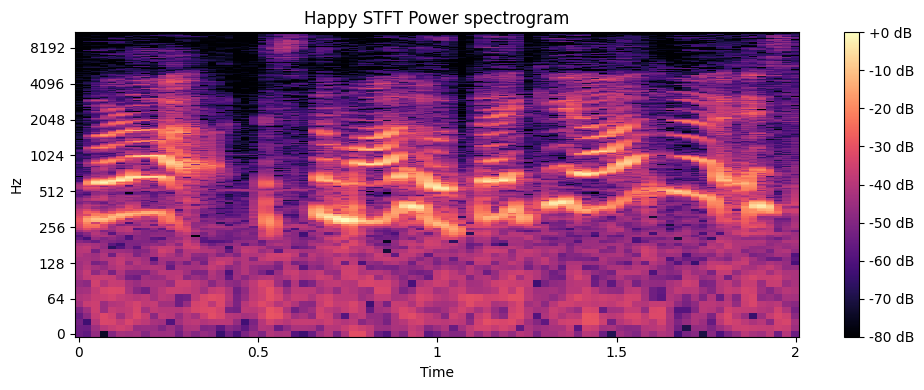

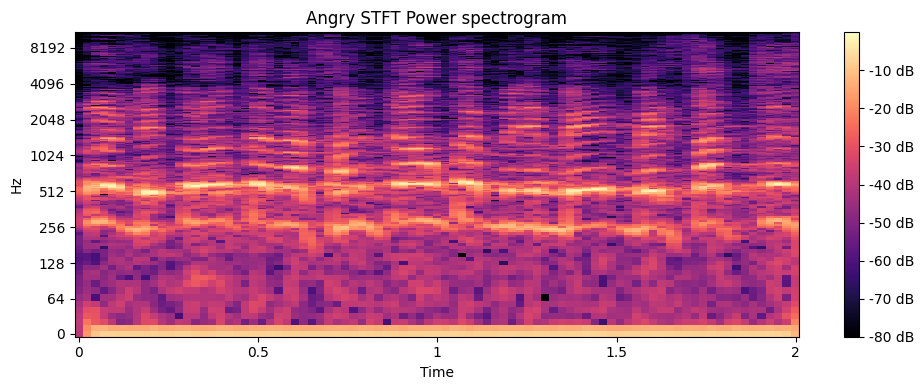

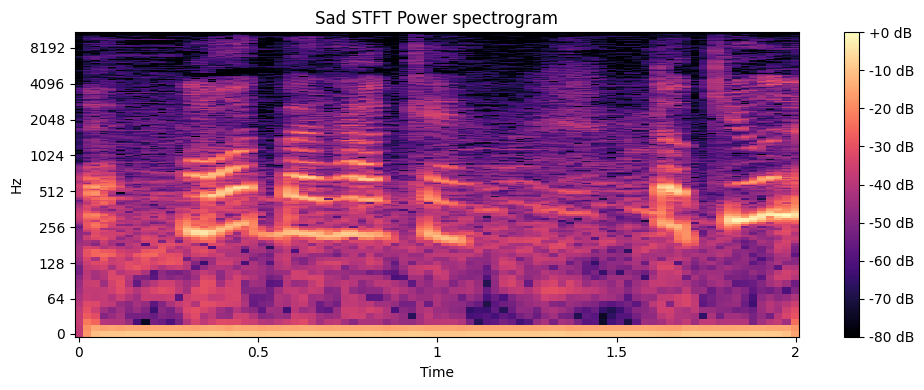

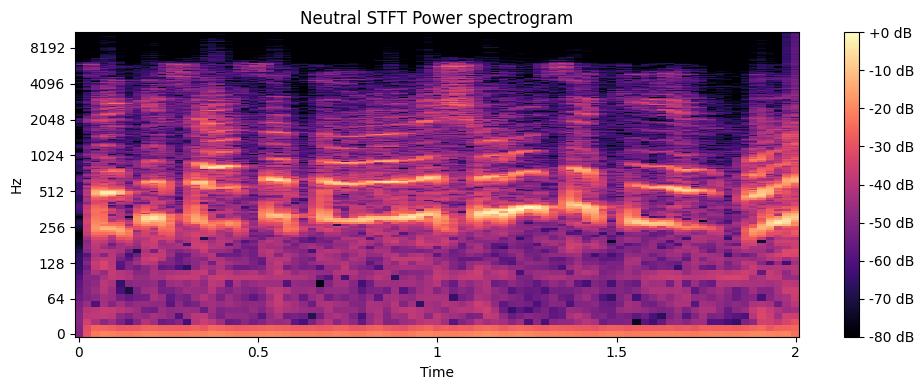

In [14]:
stft_spectrum_matrix = librosa.stft(happy_waveform)
plt.figure(figsize=(10, 4))
librosa.display.specshow(librosa.amplitude_to_db(np.abs(stft_spectrum_matrix), ref=np.max),y_axis='log', x_axis='time')
plt.title('Happy STFT Power spectrogram')
plt.colorbar(format='%+2.0f dB')
plt.tight_layout()

stft_spectrum_matrix = librosa.stft(angry_waveform)
plt.figure(figsize=(10, 4))
librosa.display.specshow(librosa.amplitude_to_db(np.abs(stft_spectrum_matrix), ref=np.max),y_axis='log', x_axis='time')
plt.title('Angry STFT Power spectrogram')
plt.colorbar(format='%+2.0f dB')
plt.tight_layout()

stft_spectrum_matrix = librosa.stft(sad_waveform)
plt.figure(figsize=(10, 4))
librosa.display.specshow(librosa.amplitude_to_db(np.abs(stft_spectrum_matrix), ref=np.max),y_axis='log', x_axis='time')
plt.title('Sad STFT Power spectrogram')
plt.colorbar(format='%+2.0f dB')
plt.tight_layout()

stft_spectrum_matrix = librosa.stft(neutral_waveform)
plt.figure(figsize=(10, 4))
librosa.display.specshow(librosa.amplitude_to_db(np.abs(stft_spectrum_matrix), ref=np.max),y_axis='log', x_axis='time')
plt.title('Neutral STFT Power spectrogram')
plt.colorbar(format='%+2.0f dB')
plt.tight_layout()

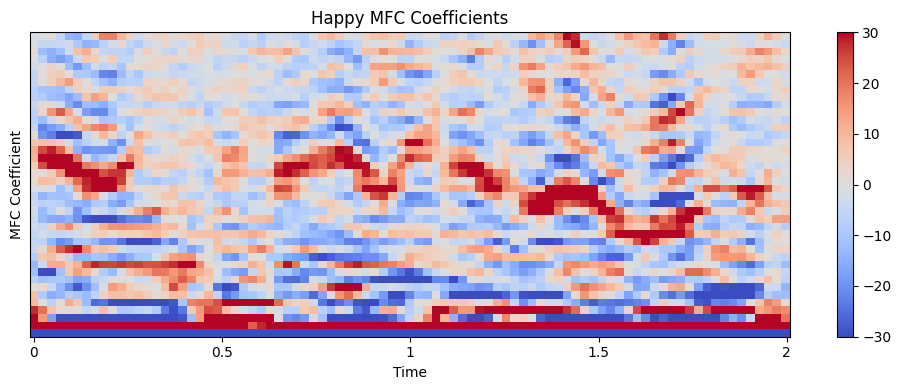

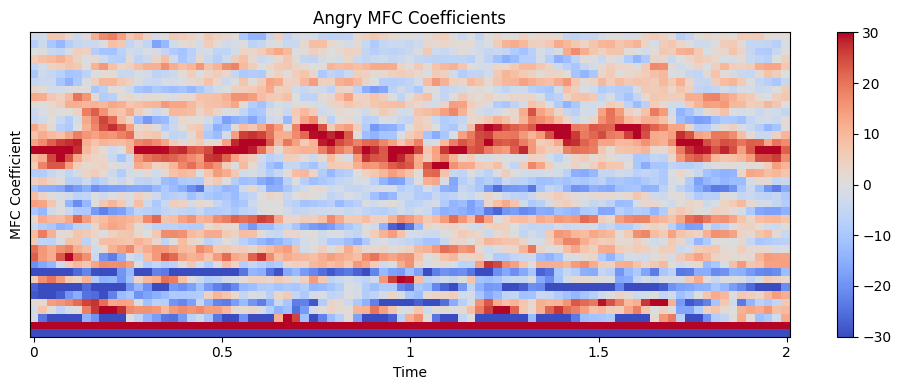

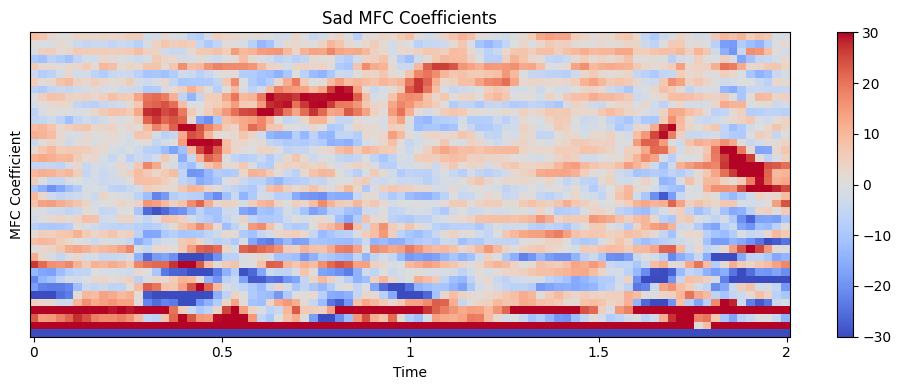

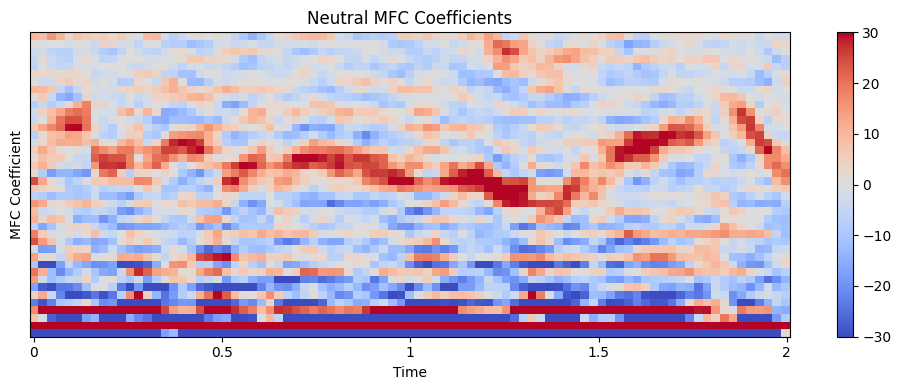

In [15]:
from matplotlib.colors import Normalize
mfc_coefficients = librosa.feature.mfcc(y=happy_waveform, sr=sample_rate, n_mfcc=40)
plt.figure(figsize=(10, 4))
librosa.display.specshow(mfc_coefficients, x_axis='time',norm=Normalize(vmin=-30,vmax=30))
plt.colorbar()
plt.yticks(())
plt.ylabel('MFC Coefficient')
plt.title('Happy MFC Coefficients')
plt.tight_layout()
                                        
mfc_coefficients = librosa.feature.mfcc(y=angry_waveform, sr=sample_rate, n_mfcc=40)
plt.figure(figsize=(10, 4))
librosa.display.specshow(mfc_coefficients, x_axis='time',norm=Normalize(vmin=-30,vmax=30))
plt.colorbar()
plt.yticks(())
plt.ylabel('MFC Coefficient')
plt.title('Angry MFC Coefficients')
plt.tight_layout()

from matplotlib.colors import Normalize
mfc_coefficients = librosa.feature.mfcc(y=sad_waveform, sr=sample_rate, n_mfcc=40)
plt.figure(figsize=(10, 4))
librosa.display.specshow(mfc_coefficients, x_axis='time',norm=Normalize(vmin=-30,vmax=30))
plt.colorbar()
plt.yticks(())
plt.ylabel('MFC Coefficient')
plt.title('Sad MFC Coefficients')
plt.tight_layout()
                                        
mfc_coefficients = librosa.feature.mfcc(y=neutral_waveform, sr=sample_rate, n_mfcc=40)
plt.figure(figsize=(10, 4))
librosa.display.specshow(mfc_coefficients, x_axis='time',norm=Normalize(vmin=-30,vmax=30))
plt.colorbar()
plt.yticks(())
plt.ylabel('MFC Coefficient')
plt.title('Neutral MFC Coefficients')
plt.tight_layout()

Positive MFCCs correspond to low-frequency regions of the cepstrum, and negative MFFCs to high-frequency.

We see the Angry voice has a much greater proportion of positive MFFCs, corresponding to a lower voice pitch compared to the Happy voice. Makes sense - a happy voice carries a lighter tone and a higher pitch.

Quick MFCC Derivation
Take the square of magnitudes in spectrograms produced by STFT to produce audio power spectrograms for short overlapping frames of the audio signal,
Apply a mel-scale-based transformation, mel filterbanks (triangular window functions) to each STFT power spectrogram and sum the power in each filterbank
Take the log of each filterbank power
Take the discrete cosine transform of each log power in each STFT frame, giving us the MFC coefficients - our measure of power at various mel frequencies, corresponding to audible pitch.

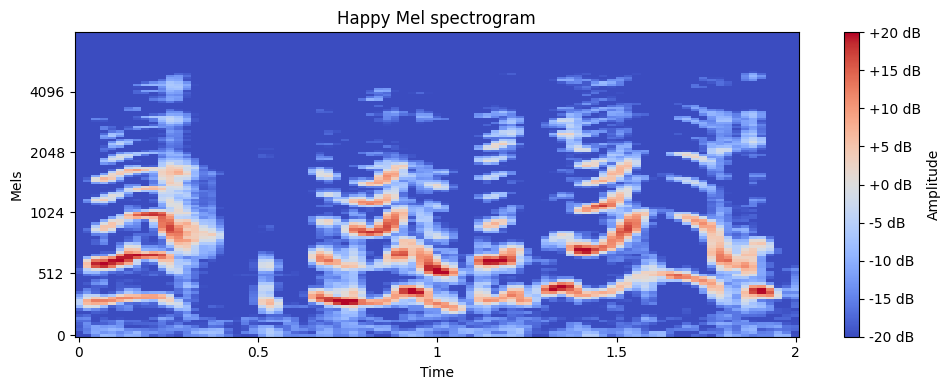

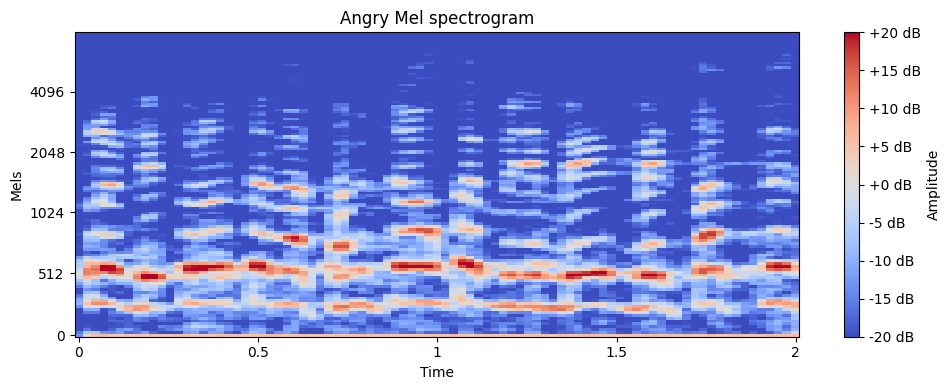

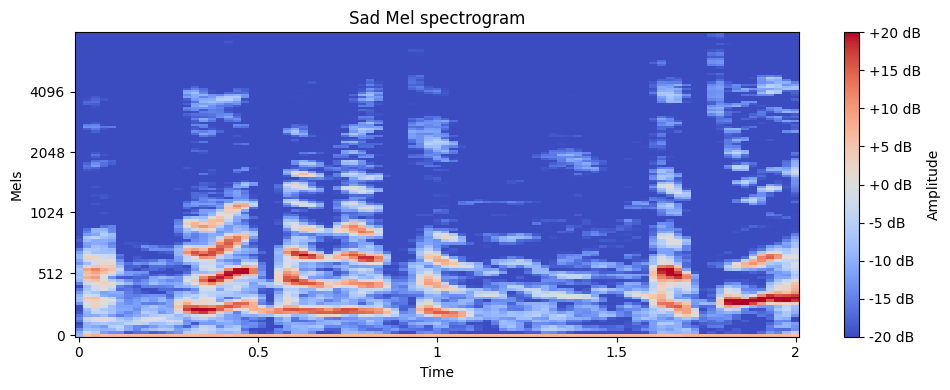

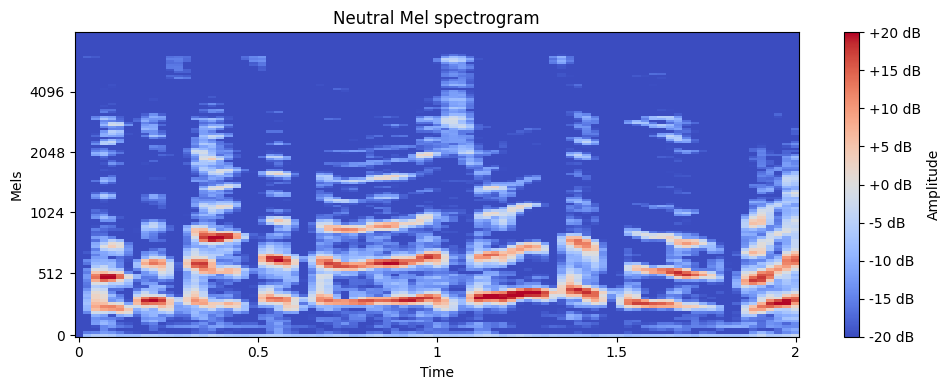

In [17]:
melspectrogram = librosa.feature.melspectrogram(y=happy_waveform, sr=sample_rate, n_mels=128, fmax=8000)
plt.figure(figsize=(10, 4))
librosa.display.specshow(librosa.power_to_db(S=melspectrogram, ref=np.mean),y_axis='mel',fmax=8000, x_axis='time', norm=Normalize(vmin=-20,vmax=20))
plt.colorbar(format='%+2.0f dB',label='Amplitude')
plt.ylabel('Mels')
plt.title('Happy Mel spectrogram')
plt.tight_layout()

melspectrogram = librosa.feature.melspectrogram(y=angry_waveform, sr=sample_rate, n_mels=128, fmax=8000)
plt.figure(figsize=(10, 4))
librosa.display.specshow(librosa.power_to_db(S=melspectrogram, ref=np.mean),y_axis='mel',fmax=8000, x_axis='time', norm=Normalize(vmin=-20,vmax=20))
plt.colorbar(format='%+2.0f dB',label='Amplitude')
plt.ylabel('Mels')
plt.title('Angry Mel spectrogram')
plt.tight_layout()

melspectrogram = librosa.feature.melspectrogram(y=sad_waveform, sr=sample_rate, n_mels=128, fmax=8000)
plt.figure(figsize=(10, 4))
librosa.display.specshow(librosa.power_to_db(S=melspectrogram, ref=np.mean),y_axis='mel',fmax=8000, x_axis='time', norm=Normalize(vmin=-20,vmax=20))
plt.colorbar(format='%+2.0f dB',label='Amplitude')
plt.ylabel('Mels')
plt.title('Sad Mel spectrogram')
plt.tight_layout()

melspectrogram = librosa.feature.melspectrogram(y=neutral_waveform, sr=sample_rate, n_mels=128, fmax=8000)
plt.figure(figsize=(10, 4))
librosa.display.specshow(librosa.power_to_db(S=melspectrogram, ref=np.mean),y_axis='mel',fmax=8000, x_axis='time', norm=Normalize(vmin=-20,vmax=20))
plt.colorbar(format='%+2.0f dB',label='Amplitude')
plt.ylabel('Mels')
plt.title('Neutral Mel spectrogram')
plt.tight_layout()

The Angry voice produces sharper transitions between mel frequency peaks compared to the Happy voice, which has smoother pitch transitions. That makes intuitive sense - an Angry voice has sharp transitions while a happy voice is more steady and pleasing to the ears. Mel spectrograms will make another good feature.

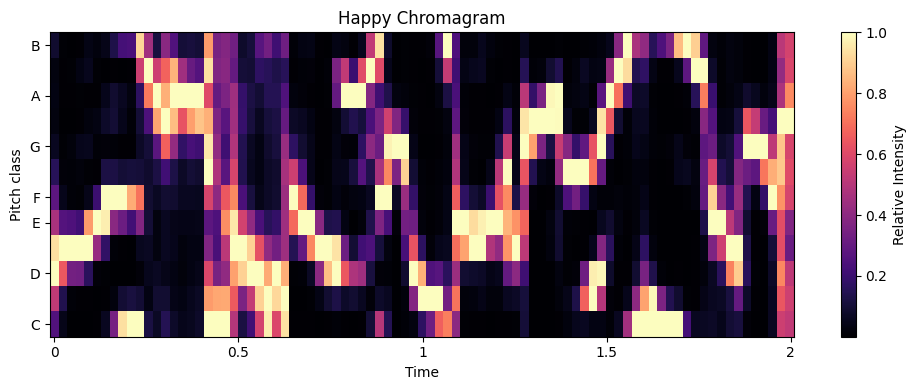

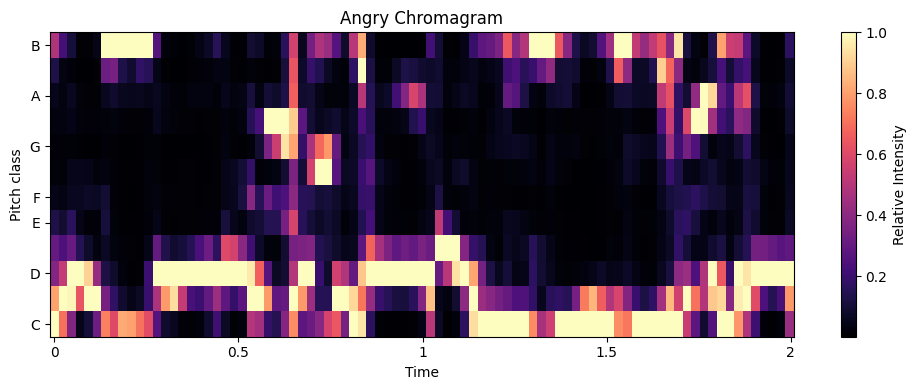

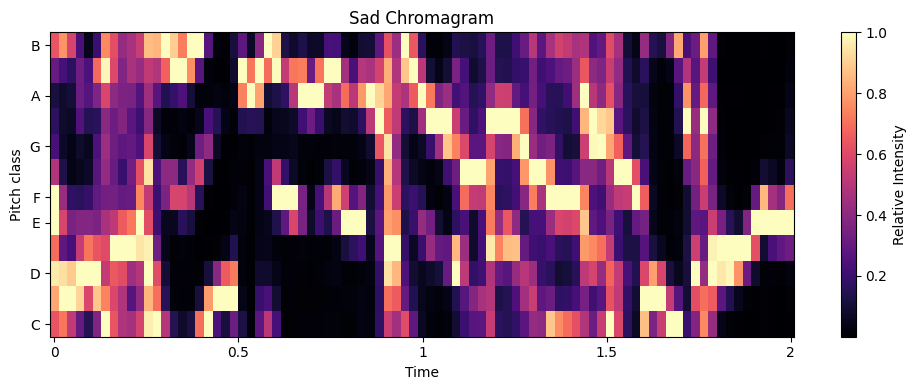

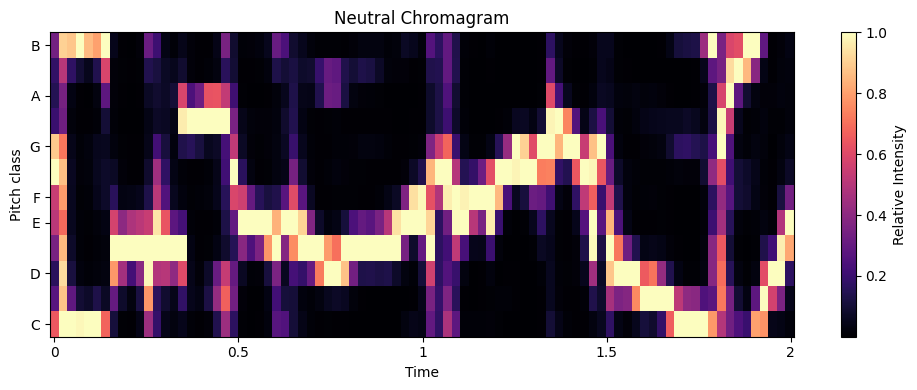

In [18]:
chromagram = librosa.feature.chroma_stft(y=happy_waveform, sr=sample_rate)
plt.figure(figsize=(10, 4))
librosa.display.specshow(chromagram, y_axis='chroma', x_axis='time')
plt.colorbar(label='Relative Intensity')
plt.title('Happy Chromagram')
plt.tight_layout()

chromagram = librosa.feature.chroma_stft(y=angry_waveform, sr=sample_rate)
plt.figure(figsize=(10, 4))
librosa.display.specshow(chromagram, y_axis='chroma', x_axis='time')
plt.colorbar(label='Relative Intensity')
plt.title('Angry Chromagram')
plt.tight_layout()

chromagram = librosa.feature.chroma_stft(y=sad_waveform, sr=sample_rate)
plt.figure(figsize=(10, 4))
librosa.display.specshow(chromagram, y_axis='chroma', x_axis='time')
plt.colorbar(label='Relative Intensity')
plt.title('Sad Chromagram')
plt.tight_layout()

chromagram = librosa.feature.chroma_stft(y=neutral_waveform, sr=sample_rate)
plt.figure(figsize=(10, 4))
librosa.display.specshow(chromagram, y_axis='chroma', x_axis='time')
plt.colorbar(label='Relative Intensity')
plt.title('Neutral Chromagram')
plt.tight_layout()

The pitch distribution of the Angry voice has a much lower dispersion compared to the Happy voice, whose pitch has a higher dispersion at any point in time. This makes intuitive sense considering the tone of an angry voice is more intense and "snappy" compared to a happy voice, which is smoother to the ears - here's a good explanation as to why. This should make a good feature.

From Here Feature Extraction Started
Each feature extraction method has its own strengths and weaknesses. 
Each block consists of various funtions of feature extraction

In [19]:
import librosa

def feature_chromagram(waveform, sample_rate):
    # STFT computed here explicitly; mel spectrogram and MFCC functions do this under the hood
    stft_spectrogram=np.abs(librosa.stft(waveform))
    # Produce the chromagram for all STFT frames and get the mean of each column of the resulting matrix to create a feature array
    chromagram=np.mean(librosa.feature.chroma_stft(S=stft_spectrogram, sr=sample_rate).T,axis=0)
    return chromagram

def feature_melspectrogram(waveform, sample_rate):
    # Produce the mel spectrogram for all STFT frames and get the mean of each column of the resulting matrix to create a feature array
    # Using 8khz as upper frequency bound should be enough for most speech classification tasks
    melspectrogram=np.mean(librosa.feature.melspectrogram(y=waveform, sr=sample_rate, n_mels=128, fmax=8000).T,axis=0)
    return melspectrogram

def feature_mfcc(waveform, sample_rate):
    # Compute the MFCCs for all STFT frames and get the mean of each column of the resulting matrix to create a feature array
    # 40 filterbanks = 40 coefficients
    mfc_coefficients=np.mean(librosa.feature.mfcc(y=waveform, sr=sample_rate, n_mfcc=40).T, axis=0) 
    return mfc_coefficients

In [20]:
def get_features(file):
    # load an individual soundfile
     with soundfile.SoundFile(file) as audio:
        waveform = audio.read(dtype="float32")
        sample_rate = audio.samplerate
        # compute features of soundfile
        chromagram = feature_chromagram(waveform, sample_rate)
        melspectrogram = feature_melspectrogram(waveform, sample_rate)
        mfc_coefficients = feature_mfcc(waveform, sample_rate)

        feature_matrix=np.array([])
        # use np.hstack to stack our feature arrays horizontally to create a feature matrix
        feature_matrix = np.hstack((chromagram, melspectrogram, mfc_coefficients))
        
        return feature_matrix

In [21]:
emotions = {
    '01':'Happy',
    '02':'Angry',
    '03':'Sad',
    '04':'Neutral'
}

In [22]:
import os, glob

def load_data():
    X,y=[],[]
    count = 0
    for file in glob.glob("C:\\xampp\\htdocs\\FYP\\Emotion-Detection-System\\processed_2_seconds_Main\\Emotion_*\\*.wav"):
        file_name=os.path.basename(file)
        emotion=emotions[file_name.split("-")[2]]
        features = get_features(file)
        X.append(features)
        y.append(emotion)
        count += 1
        # '\r' + end='' results in printing over same line
        print('\r' + f' Processed {count}/{400} audio samples',end=' ')
    # Return arrays to plug into sklearn's cross-validation algorithms
    return np.array(X), np.array(y)

In [23]:
features, emotions = load_data()

 Processed 400/400 audio samples 

In [26]:
print(f'\nAudio samples represented: {features.shape[0]}')
print(f'Numerical features extracted per sample: {features.shape[1]}')
features_df = pd.DataFrame(features) # make it pretty for display
features_df


Audio samples represented: 400
Numerical features extracted per sample: 180


,0,1,2,3,4,5,6,7,8,9,...,170,171,172,173,174,175,176,177,178,179
0,0.506535,0.488779,0.463518,0.475574,0.479455,0.510125,0.533522,0.492077,0.474217,0.501927,...,0.138771,2.393389,-0.724386,1.513121,0.813580,-1.091737,-0.024845,-0.605937,-2.514821,1.833873
1,0.473186,0.575957,0.592039,0.545399,0.523971,0.499274,0.463973,0.442157,0.433265,0.425159,...,-3.146132,-1.074520,-4.195490,-1.973722,-5.327846,0.436269,-3.713109,0.995104,-1.046181,0.210233
2,0.415692,0.415654,0.461967,0.509330,0.478297,0.435915,0.453214,0.459488,0.436623,0.415576,...,-5.792710,-0.977284,-1.731400,-0.243245,-2.629511,1.305115,-2.724668,2.753999,-1.872005,2.819712
3,0.483770,0.373059,0.274360,0.265495,0.282114,0.282347,0.280629,0.387953,0.515998,0.515481,...,-3.447417,3.165704,0.897107,-0.893733,-3.284172,1.899381,-6.236018,0.819878,-0.530224,1.463271
4,0.494442,0.474236,0.445681,0.430946,0.414969,0.434194,0.478420,0.448200,0.384383,0.393356,...,-4.663278,-3.595520,0.058614,-0.295190,-2.387944,-0.519782,-3.203753,1.533534,-1.354431,2.140934
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.509202,0.430458,0.461503,0.505563,0.629312,0.711033,0.612896,0.589813,0.559413,0.569815,...,6.137039,1.234559,3.526969,-1.693581,2.333235,-2.147898,0.113419,3.559747,-2.851303,1.825002
396,0.447255,0.436494,0.552444,0.700309,0.706667,0.590233,0.580108,0.617937,0.561344,0.622604,...,2.521219,3.185793,5.727143,0.393005,7.127913,2.397191,-2.264241,1.672050,-3.412119,-1.556805
397,0.468885,0.479910,0.476708,0.475915,0.642625,0.749106,0.618375,0.568053,0.546613,0.440445,...,-2.680907,2.339090,-2.306328,3.370839,0.919858,5.454121,5.316483,11.692389,8.289184,7.529939
398,0.575834,0.627323,0.593161,0.489276,0.585216,0.612499,0.574731,0.606777,0.593067,0.515018,...,-3.174630,2.717264,0.373683,4.787652,2.304411,6.440415,3.534609,5.354125,4.555798,4.954571


Text(0, 0.5, 'Number of Samples')

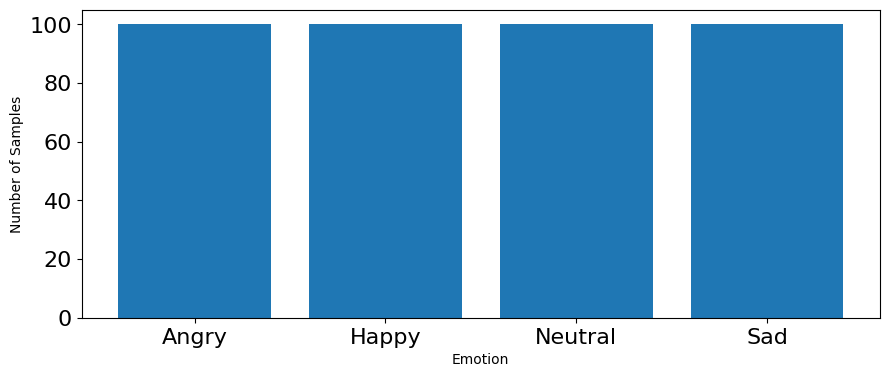

In [29]:
# plot emotions
plt.figure(figsize=(35,4))
plt.subplot(1,3,1)
#np.unique returns ordered list of unique elements and count of each element
emotion_list, count = np.unique(emotions, return_counts=True)
plt.bar(x=range(4), height=count)
plt.xticks(ticks=range(4), labels = [emotion for emotion in emotion_list],fontsize=10)
plt.xlabel('Emotion')
plt.tick_params(labelsize=16)
plt.ylabel('Number of Samples')